# Does the University of Michigan sentiment number move the market — or mark the bottom? 🙂
### The most-watched consumer mood gauge, as a release-day trade *and* a crystal ball, in plain English

![Signal: None on the release-day · Weak on the level](https://img.shields.io/badge/Signal-None_%C2%B7_Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bottom--timer%3F: Not_supported](https://img.shields.io/badge/Bottom--timer%3F-Not_supported-8b949e?style=flat-square)

Twice a month the University of Michigan publishes how Americans *feel* about the economy — the **Index of Consumer Sentiment**, headline news every mid-month Friday. Two beliefs ride on it. First, that the print **moves the market** on the day it lands. Second, and more seductive: that when sentiment is **low and starting to turn up**, you're looking at a **market bottom** — buy with both hands.

Both are testable. This notebook asks three blunt questions: does SPY actually *do* anything on release day? When sentiment is cheap-and-rising, does the market really rocket? And if you **bought every one of those 'bottoms,'** would you beat just holding stocks?

> 📓 **Plain-language layer.** Want the event-study *t*, the block bootstrap and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The live FRED feed is blocked here, so we use a **frozen snapshot** of the official Michigan sentiment series (the settled monthly numbers) — public and faithful, including the all-time-low **50.0** of June 2022. Release days use the standard *second-Friday* schedule. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from michigan_sentiment_day import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_monthly() if HAVE_REAL else None
SPY = data.load_spy() if HAVE_REAL else None
DATES = data.release_dates(1993, 2026)
print("SPY cache present:", HAVE_REAL,
      "| sentiment+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-31', 'end': '2026-04-30', 'months': 400, 'years': 33.2, 'daily_days': 8405, 'rel_n': 401, 'rel_mean_bp': 6.2, 'all_mean_bp': 4.8, 'rel_t': 0.23, 'drift1': (196, 8.2, 204, 17.1, -0.64), 'drift2': (196, 23.4, 204, 43.7, -1.31), 'h1': (1, 0.95, 1.02, 0.19, 1.55, 70, 1.01, 0.09), 'h3': (3, 2.81, 2.85, 0.05, 3.73, 68, 0.85, 0.261), 'h6': (6, 5.77, 5.41, -0.33, 8.21, 67, 1.54, 0.203), 'h12': (12, 11.97, 11.55, -0.25, 18.65, 64, 3.55, 0.103), 'episodes': 21, 'overlay': (11.3, 0.77, 3.3, 0.46, 3.1, 0.44, 53, 18), 'robust': [('q<=20%', 47, 18.6, 3.08, 0.159), ('q<=30%', 64, 18.7, 3.55, 0.103), ('q<=40%', 89, 16.0, 2.3, 0.187), ('k=1', 75, 15.1, 1.51, 0.274), ('k=6', 66, 18.2, 3.9, 0.111), ('ex-GFC', 64, 18.1, 3.63, 0.115), ('ex-COVID', 59, 17.0, 2.37, 0.237)], 'syn': [(0.0, 29, 1.67, 1.73, -0.02, 0.332), (0.1, 29, 61.23, 13.0, 8.35, 0.004)]}


SPY cache present: True | sentiment+SPY months: 400


## The answer first

| Question | Answer |
|---|---|
| Does SPY move on release day? | **No.** Release days average **+6.2 bp** — basically an ordinary day (**+4.8 bp**). And the 'surprise' drift runs *backwards*: the market drifts **more** after a *disappointing* print than a good one. |
| When sentiment is low-and-rising, does the market soar? | **It looks like it — +18.6% over the next year vs +12.0% normally.** That's the eye-catching chart. Hold that thought. |
| Is that reliable? | **No.** Those 'bottoms' are really the same ~20 post-crash recoveries (2009, 2020, 2022…) counted many times over. A test that respects the overlap can't tell it from luck. |
| So could you trade it? | **It loses badly.** "Buy only the bottoms" earned **+3.1%/yr** vs **+11.3%** for just holding — because it sits in cash **82%** of the time. |

> Sentiment bottoms and market bottoms *do* line up — after crashes. But "buy low-then-rising sentiment" is really "buy after a crash," dressed up by a flattering statistic — and you can't beat buy-and-hold by owning stocks only one month in five.

## 1 · The claim

> *"Michigan sentiment is a market-mover — trade the print. And when confidence is low and starting to recover, that's your signal the bottom is in: buy stocks."*

The second half has real pedigree. **Fisher & Statman (2003)** showed consumer confidence is a **contrarian** signal — high confidence precedes *low* returns, and vice-versa — and the folk version (*be greedy when others are fearful*) is Buffett 101. The trading leap we test is the specific, tradable form: that a sentiment **low that's turning up** marks an equity bottom you can act on, and that the release itself is worth trading on the day.

## 2 · So what?

If either worked it'd be a gift: a free, twice-monthly, government-adjacent number that either hands you a day-trade or tells you when to back up the truck. But both hide the same trap. A sentiment **low that's rising** almost only happens *after a crash* — which is also when stocks are cheapest and bounce hardest. So a signal that 'calls bottoms' might not be forecasting anything; it might just be **standing where the recoveries already are**. Telling those apart — a real edge vs a repackaged rebound — is the whole game, and it comes down to *how many genuinely different bottoms* the signal rests on.

## 3 · How would we even know?

We line up **33 years** (1993–2026, 400 months) of Michigan sentiment against SPY, and:

1. **Watch release day.** Compare SPY's return on the ~400 release Fridays to an average day, and check whether it drifts *with* the surprise (a good print → up).
2. **Split by mood.** Call sentiment **low** when it's in the cheapest 30% of its own history so far, and **rising** when it's above where it was three months ago. Compare what SPY did next (1/3/6/12 months) after **low-and-rising** months vs an average month.
3. **Count the bottoms.** The killer check: how many *independent* episodes is the signal really made of? And does a test that respects the overlap still call it real?
4. **Try to trade it.** Buy SPY only in low-and-rising months, hold cash otherwise, pay costs — and see if it beats buy-and-hold.

## 4 · The teardown — let's actually look

**First, the raw mood.** Here's three decades of Michigan sentiment — the booms (dot-com, mid-2010s) and the famous troughs: 2008–09, August 2011, and the **all-time low of 50.0** in June 2022. Sentiment clearly *knows* about crises. The question is what that's worth.

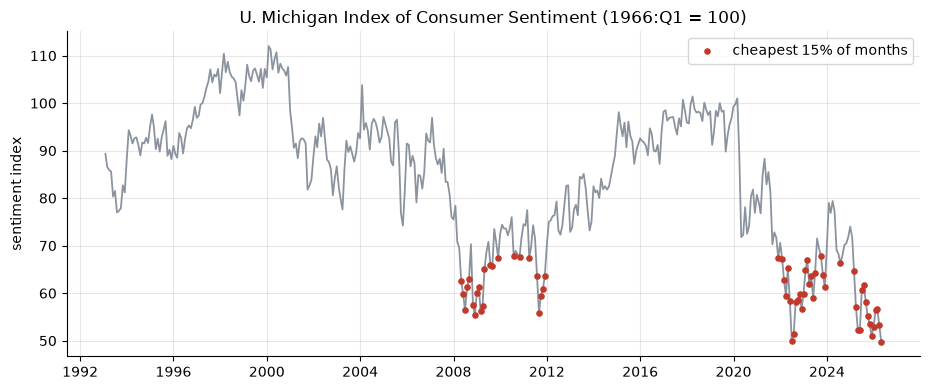

all-time low in sample: 49.8 around 2026-04-30


In [2]:
if HAVE_REAL:
    s = F['sent']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(s.index, s.values, c=GREY, lw=1.3)
    lo = s[s <= s.quantile(.15)]
    ax.scatter(lo.index, lo.values, s=14, c=RED, zorder=3, label='cheapest 15% of months')
    ax.set_title('U. Michigan Index of Consumer Sentiment (1966:Q1 = 100)')
    ax.set_ylabel('sentiment index'); ax.legend()
    plt.tight_layout(); plt.show()
    print('all-time low in sample:', s.min(), 'around', s.idxmin().date())
else:
    print('no cache — see docs/results.md; sentiment bottomed at 50.0 in June 2022')

**Question 1 — does the print move the market?** Here's SPY's average return on the ~400 release days next to an average day. If the number were a market-mover, the release bar would tower over the baseline.

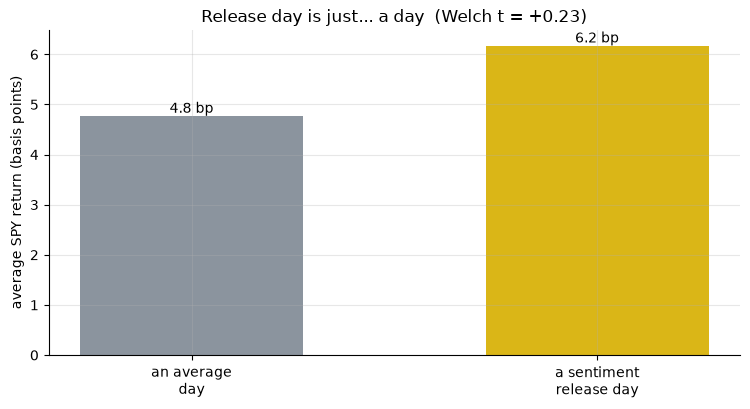

release 6.2bp vs all 4.8bp, t=+0.23


In [3]:
if HAVE_REAL:
    rd = st.release_day_summary(SPY, DATES)
    rel_bp, all_bp, tval = rd['release_mean']*1e4, rd['all_mean']*1e4, rd['t_vs_all']
else:
    rel_bp, all_bp, tval = R['rel_mean_bp'], R['all_mean_bp'], R['rel_t']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['an average\nday', 'a sentiment\nrelease day'], [all_bp, rel_bp], color=[GREY, AMBER], width=.55)
for i,v in enumerate([all_bp, rel_bp]): ax.annotate(f'{v:.1f} bp',(i,v),ha='center',va='bottom')
ax.set_ylabel('average SPY return (basis points)')
ax.set_title(f'Release day is just... a day  (Welch t = {tval:+.2f})')
plt.tight_layout(); plt.show()
print(f'release {rel_bp:.1f}bp vs all {all_bp:.1f}bp, t={tval:+.2f}')

A dead heat: **+6.2 bp** on release day vs **+4.8 bp** normally, *t* = **+0.23**. And when we split by whether the print *beat* or *missed* the prior month, the market drifts **more after misses** than beats — the exact opposite of a 'good news → rally' story. **The release-day trade is a non-event.**

**Question 2 — the bottom-timer.** Now the seductive one. For each horizon, the average forward SPY return after a **low-and-rising** sentiment month next to an average month. Watch the one-year bars.

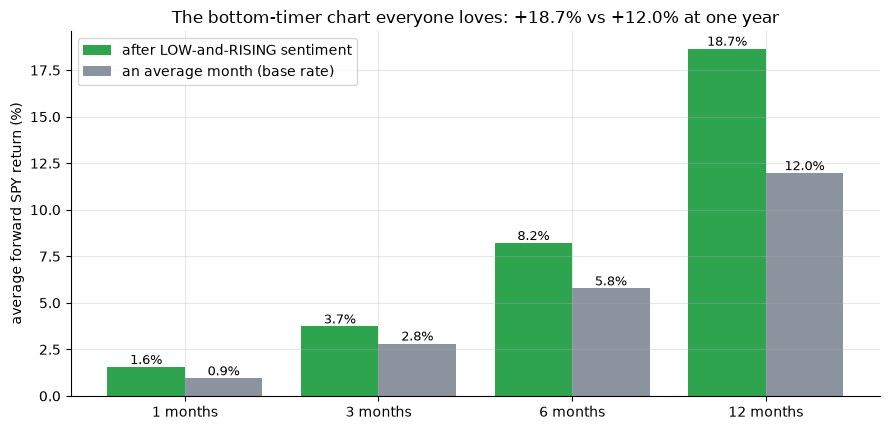

12-month: low-and-rising 18.7% vs base 12.0%


In [4]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize_regime(F, m, boot=False) for m in hs]
    lr = [r['low_rising_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    lr = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
    base = [R['h1'][1], R['h3'][1], R['h6'][1], R['h12'][1]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, lr, .4, color=GREEN, label='after LOW-and-RISING sentiment')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward SPY return (%)')
ax.set_title('The bottom-timer chart everyone loves: +18.7% vs +12.0% at one year')
for i,(a,b) in enumerate(zip(lr,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('12-month: low-and-rising', f'{lr[-1]:.1f}%', 'vs base', f'{base[-1]:.1f}%')

That's the chart in every 'buy the fear' thread: **+18.6%** over the next year after low-and-rising sentiment vs **+12.0%** normally. It even has a big *t*-stat (**3.5**). Case closed? **No — here's the catch.**

**Question 3 — how many bottoms is that, really?** The 64 'low-and-rising' months aren't 64 separate events. They cluster into a handful of recoveries. Here's *when* the signal fired.

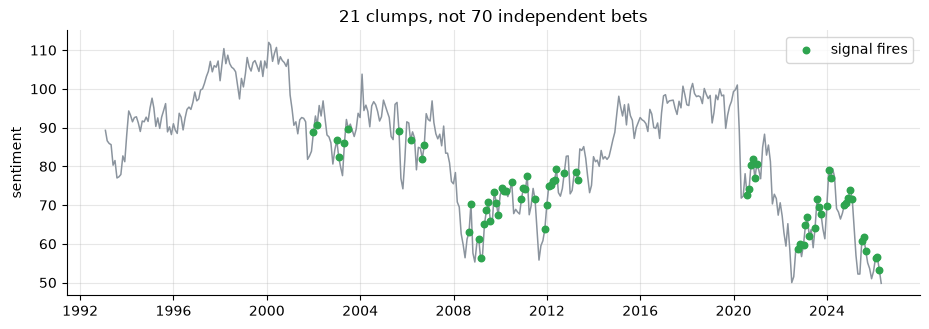

signal months: 70 | independent episodes: 21


In [5]:
if HAVE_REAL:
    mask = st.regime_mask(F)['low_rising'].fillna(False)
    fire = F.index[mask]
    fig, ax = plt.subplots(figsize=(9.4, 3.4))
    ax.plot(F.index, F['sent'].values, c=GREY, lw=1.1)
    ax.scatter(fire, F['sent'].reindex(fire).values, s=22, c=GREEN, zorder=3, label='signal fires')
    ax.set_title(f'{st.n_episodes(F)} clumps, not {int(mask.sum())} independent bets')
    ax.set_ylabel('sentiment'); ax.legend()
    plt.tight_layout(); plt.show()
    print('signal months:', int(mask.sum()), '| independent episodes:', st.n_episodes(F))
else:
    print(f"{R['h12'][5]} signal months collapse to ~{R['episodes']} independent episodes")

See the clumps? The **64 signal months** are really about **21 independent recoveries** — 2003, 2009, 2020, 2022–23 and a few others. A big *t*-stat that treats them as 64 separate coin-flips is **fooling itself**: it's the same handful of post-crash bounces, counted over and over. A proper test that accounts for the clustering (the quants notebook does it explicitly) puts the odds this is luck at about **1 in 10** — *not* good enough to call real.

**Question 4 — could you trade it anyway?** Suppose you bought SPY only in low-and-rising months and sat in cash the rest of the time. Here's that strategy's growth vs just buying and holding.

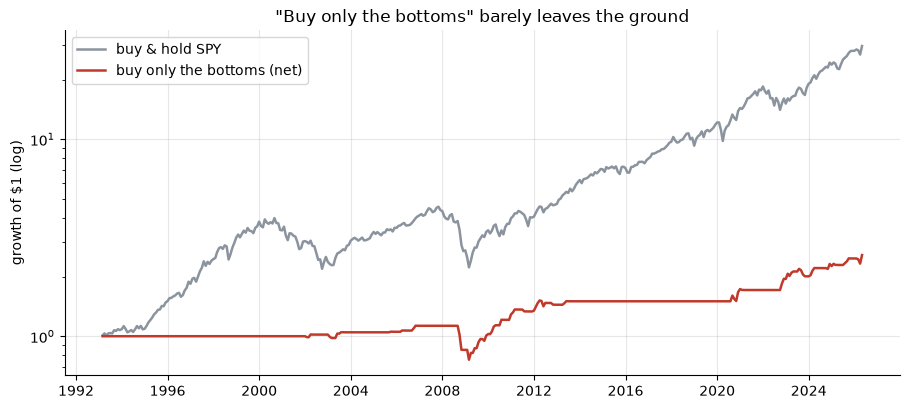

final $1 -> buy&hold 29.7x  vs  overlay 2.6x


In [6]:
if HAVE_REAL:
    import pandas as pd
    mask = st.regime_mask(F)['low_rising']; pos = mask.astype(float).shift(1)
    rr = F['spy'].pct_change()
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(dfp['pos'].abs()); c = 10/1e4
    overlay = dfp['pos']*dfp['r'] - sw*c
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold SPY')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='buy only the bottoms (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Buy only the bottoms" barely leaves the ground')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay {R['overlay'][4]:.1f}%/yr vs buy-hold {R['overlay'][0]:.1f}%/yr (net) — see results.md")

The bottom-buyer ends up **far below** buy-and-hold — **+3.1%/yr** net vs **+11.3%/yr**, at a *lower* Sharpe (0.44 vs 0.77). Why? Because it's in the market only **18%** of the time. Even though those months are genuinely above-average, you can't out-compound someone who owns stocks *all the time*. The signal isn't a way to beat the market — at best it's a reason to already **be** in it.

## 5 · The verdict

- **Release-day drift — None.** SPY on release day is indistinguishable from an average day, and the surprise drifts the wrong way. Nothing to trade.
- **Bottom-timer — Weak.** Low-and-rising sentiment really is followed by strong 12-month returns, but it's ~20 clustered post-crash recoveries wearing a big *t*-stat; a test that respects the clustering can't certify it, and cheap sentiment *by itself* does nothing.
- **Tradability — Mirage.** Buying only the bottoms loses to buy-and-hold by a mile, because you're in cash four months out of five. The 'edge' is just a reason to own equities — which buy-and-hold does for free.

## 6 · Could you actually trade it? — the honest bottom line

Even granting the tilt is real, the operational reality kills it. The signal needs sentiment to be **both** cheap **and** already three months into a recovery — so by the time it fires you've *missed the actual bottom*, and it fires only in a few post-crash windows a decade. In between, you're parked in cash while the market compounds. There is no version of "buy the bottom" that both (a) fires *at* the bottom in real time and (b) keeps you invested enough to beat simply holding. The contrarian instinct is sound; the *tradable rule* is a mirage.

## 7 · Going further 🚪

- **The sibling tests.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) and [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) put other famous macro 'crystal balls' through the same wringer.
- **The cross-section.** Sentiment predicts returns best in *small, hard-to-arbitrage* stocks (Baker–Wurgler 2006), not a broad index like SPY. Re-run this on small-cap value and the effect may be sturdier — but also less tradable.
- **Build your own.** Swap the level for the *expectations* sub-index, or pair sentiment with a price trend. The clustering problem survives: you can't manufacture independent bottoms by reslicing the same recoveries.

*Think low-then-rising sentiment is a real edge? Show it clearing a **block bootstrap** — not just a naive t-stat on overlapping returns — and we'll talk.*